In [1]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import wandb
from sklearn.metrics import f1_score
from tqdm import tqdm

In [4]:
# .npz laden
train = np.load("../Model_data/train_split1_100WS.npz")
test  = np.load("../Model_data/test_split1_100WS.npz")

X_train, y_train = train["X"], train["y"]
X_test,  y_test  = test["X"],  test["y"]

# X_train hat die Form (Anzahl Windows, Zeitschritte pro Window, Anzahl Features)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(21167, 100, 13)
(21167,)
(3969, 100, 13)
(3969,)


In [5]:
# PyTorch braucht numerische Klassen
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

# NumPy zu PyTorch Tensoren und umformen zu (N, 13, 100) (Chanels in der Mitte) für CNN, nicht bei LSTM
X_train_t = torch.tensor(X_train, dtype=torch.float32).permute(0, 2, 1)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32).permute(0, 2, 1)

y_train_t = torch.tensor(y_train_enc, dtype=torch.long)
y_test_t  = torch.tensor(y_test_enc,  dtype=torch.long)

# Datasets erstellen als Tensoren
train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t,  y_test_t)

# GPU falls verfügbar
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [6]:
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\jessi\_netrc.
wandb: Currently logged in as: jessischmid01 (CDL1_team) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

# 1D-CNN Aufbau

In [7]:
class CNN1D(nn.Module):
    def __init__(self, n_features, n_classes, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(n_features, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        return self.classifier(self.net(x))
    

class ResidualBlock(nn.Module):
    def __init__(self, channels, dropout=0.3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(channels),
            nn.ReLU(),
            nn.Dropout(dropout),  # Dropout direkt nach Aktivierung
            nn.Conv1d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(channels),
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(x + self.block(x))

class CNN1D_Residual(nn.Module):
    def __init__(self, n_features, n_classes, dropout=0.4):
        super().__init__()
        # Eingangsblock, welcher rohe Daten verarbeitet
        self.stem = nn.Sequential(
            nn.Conv1d(n_features, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )
        self.res1 = ResidualBlock(64, dropout)

        # downsampling-Schicht, Sequenzlänge wird halbiert durch stride = 2
        self.down1 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1, stride=2),
            nn.BatchNorm1d(128), nn.ReLU()
        )
        self.res2 = ResidualBlock(128, dropout)
        self.pool = nn.AdaptiveAvgPool1d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.res1(x)
        x = self.down1(x)
        x = self.res2(x)
        x = self.pool(x)
        return self.classifier(x)

## Namensgebungen

Die Bezeichnungen der Durchläufe haben sich im Laufe der Zeit geändert: 1D-CNN_v3... Die verschiedenen Versionen sind:

- Version 1 war ohne Datenaugmentierung und andere Verfeinerungen
- Version 2 nutzt Datenaugmentierung und ein Learningrate scheduler eingebaut, verwendet aber noch die alte Datenaufteilung
- Version 3 nutzt die neue Aufteilung in Trainings- und Testdaten, bei der wir die Daten nach Benutzern getrennt haben
- Version 4 hat label_smoothing=0.1 im criterion, mehr Daten Agumentation und hat eine eingebauten ResidualBlock (Skipconnection) wegen Vanashing Gradient
- Version 5 neuer Split mit besserer Aufteilung der Personen auf die Klassen ohne Überschneidungen


In [9]:
def evaluate(model, loader, criterion, device):
    """
    Gibt loss, accuracy und f1-macro für einen DataLoader zurück.
    Wird für Train- und Validation-Set verwendet.
    """
    model.eval()
    total_loss, correct = 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch)
            total_loss += criterion(preds, y_batch).item()
            correct += (preds.argmax(1) == y_batch).sum().item()
            all_preds.extend(preds.argmax(1).cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    n = len(loader.dataset)
    avg_loss = total_loss / len(loader)
    acc = correct / n
    f1 = f1_score(all_labels, all_preds, average="macro")

    return {"loss": avg_loss, "acc": acc, "f1": f1}

def augment(X_batch):
        # Gaussian Noise
    X_batch = X_batch + torch.randn_like(X_batch) * 0.01

    # Amplitude Scaling: pro Sample ein zufälliger Faktor zwischen 0.9 und 1.1
    scale = 0.9 + torch.rand(X_batch.size(0), 1, 1, device=X_batch.device) * 0.2
    X_batch = X_batch * scale

    # Channel Dropout: einzelne Sensorkanäle auf 0 setzen
    B, C, T = X_batch.shape
    if torch.rand(1).item() < 0.3:
        ch = torch.randint(0, C, (1,)).item()
        X_batch[:, ch, :] = 0

    # Time Warping: zufälliger zeitlicher Shift
    shift = torch.randint(-10, 10, (1,)).item()
    X_batch = torch.roll(X_batch, shifts=shift, dims=2)

    # Magnitude Warping: per-Kanal leichte Skalierung
    mag = 0.95 + torch.rand(B, C, 1, device=X_batch.device) * 0.1
    X_batch = X_batch * mag
    return X_batch

def train(config, train_ds, test_ds, device, project="CDL1"):
    """
    Trainiert ein CNN1D Modell mit den gegebenen Hyperparametern.

    Args:
        config: Dictionary mit allen Hyperparametern
        train_loader: DataLoader für Trainingsdaten
        test_loader: DataLoader für Validierungsdaten
        device: torch.device (cuda / cpu)
        project: W&B Projektname

    Returns:
        model: Trainiertes Modell (bestes nach val/f1)
        history: Dictionary mit Metriken pro Epoch
    """
    # Wandb Run initialisieren
    fold_suffix = f"_Fold{config['fold']}" if "fold" in config else ""
    run = wandb.init(
        project=project,
        entity="CDL1_team",
        config=config,
        name=f"1D-CNN-Res_v5_lr{config['lr']}_bs{config['batch_size']}_do{config['dropout']}{fold_suffix}"
    )
    cfg = wandb.config

    # DataLoader wird jetzt mit der config Batch Size erstellt
    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True)
    test_loader = DataLoader(test_ds,  batch_size=cfg.batch_size, shuffle=False)

    # Modell, Optimizer, Loss festlegen, Adam passt die Lernrate während dem Training an
    model = CNN1D_Residual(cfg.n_features, cfg.n_classes, dropout=cfg.dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)

    wandb.watch(model, log="all", log_freq=50)

    # Variablen um beste F1 Scores und die dazugehörigen Gewichte zu speichern
    history = {"train": [], "val": []}
    best_f1 = 0.0
    best_state = None

    # hinzufügen von tqdm, damit man den Fortschritt sieht
    epoch_bar = tqdm(range(cfg.epochs), desc="Training", unit="epoch")

    for epoch in epoch_bar:

        model.train()
        train_loss, train_correct = 0, 0
        all_preds, all_labels = [], []

        batch_bar = tqdm(train_loader, desc=f"  Epoch {epoch+1:02d}", leave=False, unit="batch")

        for X_batch, y_batch in batch_bar:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            X_batch = augment(X_batch)

            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_correct += (preds.argmax(1) == y_batch).sum().item()
            all_preds.extend(preds.argmax(1).cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
            
            # Aktuellen Loss direkt im Batch-Balken anzeigen
            batch_bar.set_postfix(loss=f"{loss.item():.3f}")

        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]

        train_metrics = {
            "loss": train_loss / len(train_loader),
            "acc": train_correct / len(train_loader.dataset),
            "f1": f1_score(all_labels, all_preds, average="macro"),
        }

        # Validation
        val_metrics = evaluate(model, test_loader, criterion, device)

        # Bestes Modell speichern
        if val_metrics["f1"] > best_f1:
            best_f1 = val_metrics["f1"]
            best_state = model.state_dict().copy()

        # History & W&B loggen 
        history["train"].append(train_metrics)
        history["val"].append(val_metrics)

        wandb.log({
            "epoch": epoch + 1,
            "train/loss": train_metrics["loss"],
            "train/acc": train_metrics["acc"],
            "train/f1": train_metrics["f1"],
            "val/loss": val_metrics["loss"],
            "val/acc": val_metrics["acc"],
            "val/f1": val_metrics["f1"],
            "train/lr": current_lr,
        })

        # Epoch-Balken mit finalen Metriken aktualisieren
        epoch_bar.set_postfix({
            "train_f1": f"{train_metrics['f1']:.3f}",
            "val_f1": f"{val_metrics['f1']:.3f}",
            "val_acc": f"{val_metrics['acc']:.3f}",
        })

    # Bestes Modell laden und zurückgeben
    model.load_state_dict(best_state)
    wandb.unwatch(model)
    wandb.finish()

    return model, history

In [23]:
# windowing_size und step_size sind im sliding window der Datenbearbeitung vorhanden und dienen nur der Dokumentation
config = {
    "model": "1D-CNN",
    "window_size": 100,
    "step_size": 50,
    "batch_size": 32,
    "lr": 0.001,
    "epochs": 30,
    "n_features": 13,
    "n_classes": len(le.classes_),
    "dropout": 0.2
}

model, history = train(
    config = config,
    train_ds = train_ds,
    test_ds = test_ds,
    device = device,
    project = "CDL1"
)

Training: 100%|██████████| 30/30 [03:48<00:00,  7.62s/epoch, train_f1=0.943, val_f1=0.583, val_acc=0.717]


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/acc,▁▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇███████████
train/f1,▁▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇█████████
train/loss,█▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁
train/lr,█████▇▇▇▇▆▆▆▅▅▅▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁
val/acc,▅▁▂▄▅▆▆▇▇▇▆█▆▆▆▆▆▅▆▇█▆▇▇▇▇▆▇▆▆
val/f1,▄▂▅▁▅▃▂▆▅▆▃█▃▃▄▃▅▂▃▅█▄▆▅▅▆▄▅▅▄
val/loss,▄█▆▅▅▂▂▃▃▃▅▃▄▅▂▂▂▃▃▂▁▃▂▂▂▂▂▂▂▂
epoch,30
train/acc,0.97255
train/f1,0.94258


# Erwartungen Gridsearch

Batchsize beeinflusst die Varianz der Gradienten, somit sind die Updates ungenauer, wenn wir eine kleine Batchsize haben. Dafür kann man mit tiefen Batchsizes eher einem lokalen Minima entweichen und besser generalisieren. Um Stabilität im Training zu haben, muss dafür bei kleiner Batchsize die Lernrate auch klein sein. Für grössere Batchsizes, können dafür grössere Lernraten verwendet werden. 

Dropout ist eine Regularisierungsmethode, bei dem im Fully connected Layer eine gewisse Prozentzahl an Neuronen zufällig ausgeschalten werden. So sollte das Overfitting reduziert werden. 

Folglich sollten folgende Kombinationen gut funktionieren:

lr: 0.01 + bs: 128 + do: 0.4
lr: 0.001 + bs: 64 + do: 0.4
lr: 0.0001 + bs: 32 + do: 0.4

In [10]:
import itertools

# Grid 1 definieren
param_grid = {
    "lr": [0.01, 0.001, 0.0001],
    "batch_size": [32, 64],
    "dropout": [0.2, 0.3, 0.5],
}

# Alle Kombinationen erzeugen
keys, values = zip(*param_grid.items())
combinations = list(itertools.product(*values))
print(f"Gesamt: {len(combinations)} Kombinationen")

# Ergebnisse sammeln
results = []

for i, combo in enumerate(combinations, 1):
    params = dict(zip(keys, combo))
    print(f"\n[{i}/{len(combinations)}] {params}")

    cfg = {
        "model": "1D-CNN",
        "window_size": 100,
        "step_size": 50,
        "epochs": 20,
        "n_features": 13,
        "n_classes": len(le.classes_),
        **params,  # lr, batch_size, dropout werden überschrieben
    }

    model, history = train(
        config = cfg,
        train_ds = train_ds,
        test_ds = test_ds,
        device = device,
        project = "CDL1",
    )

    # Bestes val/f1 aus der History holen
    best_val_f1 = max(e["f1"]  for e in history["val"])
    best_val_acc = max(e["acc"] for e in history["val"])

    results.append({
        **params,
        "best_val_f1": best_val_f1,
        "best_val_acc": best_val_acc,
        "model": model,
        "history": history,
    })

    print(f" best val/f1: {best_val_f1:.4f}  |  best val/acc: {best_val_acc:.4f}")

# Nach F1 sortieren und Top-3 ausgeben
results.sort(key=lambda x: x["best_val_f1"], reverse=True)


Gesamt: 18 Kombinationen

[1/18] {'lr': 0.01, 'batch_size': 32, 'dropout': 0.2}


Training: 100%|██████████| 20/20 [02:36<00:00,  7.83s/epoch, train_f1=0.952, val_f1=0.767, val_acc=0.815]


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/acc,▁▅▆▆▆▇▇▇▇▇▇█████████
train/f1,▁▅▆▆▇▇▇▇▇▇██████████
train/loss,█▅▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁
train/lr,███▇▇▇▆▆▅▅▄▃▃▂▂▂▁▁▁▁
val/acc,▆▇▆▇▁▇▅▂▅▅▆▅▅▇▆▅▅▇█▇
val/f1,▄▇▅▆▁▂▄▂▃▄▅▃▃▆▅▄▅▆█▇
val/loss,▃▃▃▂█▃▆█▄▅▃▄▅▃▂▄▄▂▁▂
epoch,20
train/acc,0.97005
train/f1,0.95219


 best val/f1: 0.7765  |  best val/acc: 0.8251

[2/18] {'lr': 0.01, 'batch_size': 32, 'dropout': 0.3}


Training: 100%|██████████| 20/20 [02:46<00:00,  8.33s/epoch, train_f1=0.951, val_f1=0.737, val_acc=0.781]


...

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/acc,▁▅▆▇▇▇▇▇████████████
train/f1,▁▅▆▇▇▇▇█████████████
train/loss,█▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
train/lr,███▇▇▇▆▆▅▅▄▃▃▂▂▂▁▁▁▁
val/acc,▁▅▅█▆▅▇▇▇▇█▇▅▇▇▇▇▆▇▇
val/f1,▁▄▆▇▇▆█▇▇▇█▇▇▇▇▇▇▇▇▇
val/loss,█▃▄▁▆▆▂▂▁▃▁▂▅▂▃▃▃▃▃▂
epoch,20
train/acc,0.96693
train/f1,0.94799


 best val/f1: 0.7223  |  best val/acc: 0.7659

[18/18] {'lr': 0.0001, 'batch_size': 64, 'dropout': 0.5}


Training: 100%|██████████| 20/20 [01:39<00:00,  4.99s/epoch, train_f1=0.929, val_f1=0.696, val_acc=0.746]


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/acc,▁▆▆▇▇▇▇█████████████
train/f1,▁▅▆▇▇▇▇█████████████
train/loss,█▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
train/lr,███▇▇▇▆▆▅▅▄▃▃▂▂▂▁▁▁▁
val/acc,▁▃▃▄▄▆▆█▆▆▆▆█▄▇▆▅▇▆▇
val/f1,▁▄▅▆▇▇▇█▇▇▇▇█▇█▇▇▇▇▇
val/loss,▇██▄▅▄▄▁▁▄▂▃▁▅▁▃▃▂▂▁
epoch,20
train/acc,0.95743
train/f1,0.92872


 best val/f1: 0.7140  |  best val/acc: 0.7632


In [11]:
print("\n" + "="*60)
print("TOP 3 KONFIGURATIONEN")
print("="*60)
for rank, r in enumerate(results[:3], 1):
    print(f"\n#{rank}  val/f1={r['best_val_f1']:.4f}  acc={r['best_val_acc']:.4f}")
    print(f"     lr={r['lr']}  batch_size={r['batch_size']}  dropout={r['dropout']}")

# Bestes Modell direkt verfügbar
best = results[0]
best_model = best["model"]
print(f"\nBestes Modell geladen: lr={best['lr']}, bs={best['batch_size']}, do={best['dropout']}")


TOP 3 KONFIGURATIONEN

#1  val/f1=0.7840  acc=0.8234
     lr=0.001  batch_size=64  dropout=0.2

#2  val/f1=0.7765  acc=0.8251
     lr=0.01  batch_size=32  dropout=0.2

#3  val/f1=0.7743  acc=0.8327
     lr=0.01  batch_size=64  dropout=0.2

Bestes Modell geladen: lr=0.001, bs=64, do=0.2


## Ergebnisse Gridsearch

Die Ergebnisse von den ersten Versüchen mit der falschen Datenaufteilung sind nur auf WanDB zu finden. Die Ergebnisse mit dem Model CNN1D sind unterhalb zu finden. 

In [2]:
from IPython.display import IFrame

In [9]:
wandb.login()
IFrame(
    "https://api.wandb.ai/links/CDL1_team/kmdd9ktm",
    width=1100, height=600
)

In [8]:
wandb.login()
IFrame(
    "https://api.wandb.ai/links/CDL1_team/lkbb7jci",
    width=1100, height=600
)

# Cross-Validation

Als nächstes wird die Cross-Validation 5-Fold auf das Model mit der besten Parameterkombination angewendet. So sieht man auch wie gross die Varianz zwischen den Vorhersagen ist. 

In [14]:
from sklearn.model_selection import StratifiedKFold

best_config = {
    "model":       "1D-CNN",
    "window_size": 100,
    "step_size":   50,
    "epochs":      30,
    "n_features":  13,
    "n_classes":   len(le.classes_),
    "lr":          0.01,
    "batch_size":  32,
    "dropout":     0.3,
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_t, y_train_t), 1):
    print(f"\n{'='*40}\nFold {fold}/5\n{'='*40}")

    fold_train_ds = TensorDataset(X_train_t[train_idx], y_train_t[train_idx])
    fold_val_ds   = TensorDataset(X_train_t[val_idx],   y_train_t[val_idx])

    _, history = train(
        config = {**best_config, "fold": fold},
        train_ds = fold_train_ds,
        test_ds = fold_val_ds,
        device = device,
        project = "CDL1",
    )

    best_f1  = max(e["f1"]  for e in history["val"])
    best_acc = max(e["acc"] for e in history["val"])
    fold_results.append({"fold": fold, "f1": best_f1, "acc": best_acc})
    print(f"Fold {fold} --> F1: {best_f1:.4f} | Acc: {best_acc:.4f}")

print(f"\n{'='*40}\nFinales Modell (alle Trainingsdaten)\n{'='*40}")

final_model, final_history = train(
    config   = {**best_config, "fold": "final"},
    train_ds = TensorDataset(X_train_t, y_train_t),
    test_ds  = TensorDataset(X_test_t,  y_test_t),
    device   = device,
    project  = "CDL1",
)

final_f1  = max(e["f1"]  for e in final_history["val"])
final_acc = max(e["acc"] for e in final_history["val"])

f1s  = [r["f1"]  for r in fold_results]
accs = [r["acc"] for r in fold_results]

print("\n" + "="*40)
print("ERGEBNIS")
print("="*40)
for r in fold_results:
    print(f"  Fold {r['fold']}: F1={r['f1']:.4f} | Acc={r['acc']:.4f}")
print(f"{'─'*40}")
print(f"  CV Mean:  F1={np.mean(f1s):.4f} | Acc={np.mean(accs):.4f}")
print(f"  CV Std:   F1={np.std(f1s):.4f}  | Acc={np.std(accs):.4f}")
print(f"{'─'*40}")
print(f"  Final:    F1={final_f1:.4f} | Acc={final_acc:.4f}  ← Testset")


Fold 1/5


Training: 100%|██████████| 30/30 [03:23<00:00,  6.77s/epoch, train_f1=0.959, val_f1=0.965, val_acc=0.979]


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/acc,▁▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇███████████
train/f1,▁▄▅▆▆▆▇▇▇▇▇▇▇▇▇▇▇█████████████
train/loss,█▅▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
train/lr,█████▇▇▇▇▆▆▆▅▅▅▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁
val/acc,▁▅▅▆▆▆▆▆▆▆▇▇▇▆▇▇▇▇▇██▇▇▇█▇████
val/f1,▁▃▄▅▅▆▅▅▆▆▆▆▆▆▇▆▇▇▆▇█▇▇▇█▇████
val/loss,█▅▄▄▃▃▄▄▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▂▁▁▁▁
epoch,30
train/acc,0.97325
train/f1,0.95863


Fold 1 --> F1: 0.9702 | Acc: 0.9813

Fold 2/5


Training: 100%|██████████| 30/30 [03:27<00:00,  6.91s/epoch, train_f1=0.950, val_f1=0.963, val_acc=0.977]


...

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/acc,▁▅▆▆▆▇▇▇▇▇▇▇▇▇▇███████████████
train/f1,▁▅▆▇▇▇▇▇▇▇████████████████████
train/loss,█▅▄▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/lr,█████▇▇▇▇▆▆▆▅▅▅▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁
val/acc,▁▄▃▆▅▆▅▇▅▇▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇█▇██
val/f1,▁▄▃▆▂▆▆▆▆▇▆▆▇▆▇▇▇▇▇▇▇▇▇▇▇▇█▇▇▇
val/loss,█▇▆▄▅▃▄▃▄▃▄▃▃▂▂▂▂▂▂▂▂▁▁▁▁▂▁▁▁▁
epoch,30
train/acc,0.96793
train/f1,0.94696


Fold 5 --> F1: 0.9616 | Acc: 0.9754

Finales Modell (alle Trainingsdaten)


Training: 100%|██████████| 30/30 [04:15<00:00,  8.53s/epoch, train_f1=0.952, val_f1=0.779, val_acc=0.821]


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/acc,▁▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇██████████████
train/f1,▁▅▆▆▆▇▇▇▇▇▇▇▇▇▇███████████████
train/loss,█▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
train/lr,█████▇▇▇▇▆▆▆▅▅▅▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁
val/acc,▁▆█▅▂▃▆▃▅▅▁▃▅▇▆▅█▃▅▅▃▅▅▄▆▆▇▅▆▆
val/f1,▁▅▇▆▅▆▆▄▆▆▄▅▆▇▇▆█▅▆▆▆▇▇▆▇▇█▇▇▇
val/loss,█▃▁▄▅▄▃▇▃▃█▅▃▂▃▃▁▆▄▄▅▄▄▆▂▃▂▄▃▃
epoch,30
train/acc,0.97175
train/f1,0.95245



ERGEBNIS
  Fold 1: F1=0.9702 | Acc=0.9813
  Fold 2: F1=0.9633 | Acc=0.9773
  Fold 3: F1=0.9642 | Acc=0.9766
  Fold 4: F1=0.9619 | Acc=0.9764
  Fold 5: F1=0.9616 | Acc=0.9754
────────────────────────────────────────
  CV Mean:  F1=0.9642 | Acc=0.9774
  CV Std:   F1=0.0031  | Acc=0.0021
────────────────────────────────────────
  Final:    F1=0.7936 | Acc=0.8511  ← Testset


In [38]:
print("\n" + "="*40)
print("ERGEBNIS")
print("="*40)
for r in fold_results:
    print(f"  Fold {r['fold']}: F1={r['f1']:.4f} | Acc={r['acc']:.4f}")
print(f"{'─'*40}")
print(f"  CV Mean:  F1={np.mean(f1s):.4f} | Acc={np.mean(accs):.4f}")
print(f"  CV Std:   F1={np.std(f1s):.4f}  | Acc={np.std(accs):.4f}")
print(f"{'─'*40}")
print(f"  Final:    F1={final_f1:.4f} | Acc={final_acc:.4f}  (auf Testset)")


ERGEBNIS
  Fold 1: F1=0.9689 | Acc=0.9831
  Fold 2: F1=0.9617 | Acc=0.9821
  Fold 3: F1=0.9684 | Acc=0.9838
  Fold 4: F1=0.9555 | Acc=0.9763
  Fold 5: F1=0.9665 | Acc=0.9841
────────────────────────────────────────
  CV Mean:  F1=0.9642 | Acc=0.9819
  CV Std:   F1=0.0050  | Acc=0.0029
────────────────────────────────────────
  Final:    F1=0.6998 | Acc=0.7777  (auf Testset)


## Cross Validation Ergebnisse

Die Vorherigen Ergebnisse sind auf WanDB einzeln zu finden. 

In [23]:
wandb.login()
IFrame(
    "https://api.wandb.ai/links/CDL1_team/sso3cy0j",
    width=1100, height=600
)

## Confusion Matrix

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os

def plot_confusion_matrix(model, loader, device, class_names, save_path= None, name= None):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            preds = model(X_batch).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    fig, ax = plt.subplots(figsize=(9, 7))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Gespeichert: {save_path}")

    plt.show()

Gespeichert: Confusion_Matrix/CNN1D_Residual_lr0.01_bs32_do0.3.png


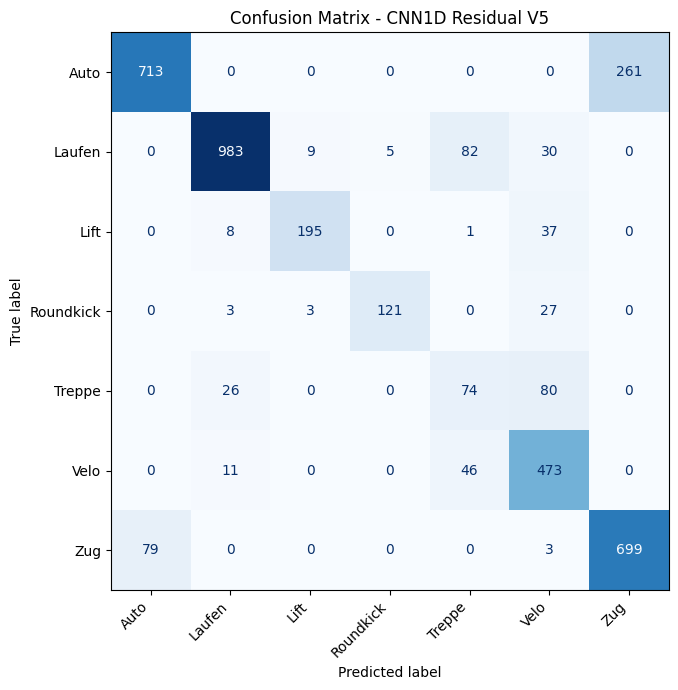

In [17]:
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

plot_confusion_matrix(
    model = final_model,
    loader = test_loader,
    device = device,
    class_names = le.classes_,   # gibt die originalen Label-Namen wie "Zug" und "Auto"
    name = "Confusion Matrix - CNN1D Residual V5",
    save_path= "Confusion_Matrix/CNN1D_Residual_lr0.01_bs32_do0.3.png"
)